# Generation and post-analysis in a simulated dataset 

#### Associated publication
Reference: https://www.nejm.org/doi/full/10.1056/NEJM199709113371101

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tableone import TableOne
import torch
from sksurv.nonparametric import kaplan_meier_estimator
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization, metrics
from simulations import *

module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

from synthcity.metrics.plots import plot_tsne
from synthcity.metrics.eval import Metrics
from synthcity.metrics.scores import ScoreEvaluator
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.utils.reproducibility import clear_cache, enable_reproducible_results

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [34]:
n_samples = 600
n_features_bytype = 6
n_active_features = 3 
treatment_effect = 0.4
p_treated = 0.5
shape_T = 2.
shape_C = 2.
scale_C = 2.5
scale_C_indep = 3.9
feature_types_list = ["real", "cat"]
independent = True
data_types_create = True

In [35]:
seed = 1
dataset_name = "Simulations"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
miss_file = parent_path + "/dataset/" + dataset_name + "/Missing.csv"
true_miss_file = None
control, treated, types = simulation(treatment_effect, n_samples, independent, feature_types_list,
                                        n_features_bytype, n_active_features, p_treated, shape_T, shape_C,
                                        scale_C, scale_C_indep, data_types_create, seed=seed)
print("Censoring level of control ", 1 - (control.censor.sum() / control.censor.shape[0]))
print("Censoring level of treated ", 1 - (treated.censor.sum() / treated.censor.shape[0]))


control = control.drop(columns='treatment')
treated = treated.drop(columns='treatment')

data_file_control = parent_path + "/dataset/" + dataset_name + "/data_control.csv"
data_file_treated = parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

control.to_csv(data_file_control, index=False , header=False)
treated.to_csv(data_file_treated, index=False , header=False)
types.to_csv(feat_types_file_control)
types.to_csv(feat_types_file_treated)


# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _, dict_cat_map_control = data_processing.read_data(data_file_control, feat_types_file_control,
                                                                                                                                         miss_file, true_miss_file,
                                                                                                                                         return_cat_mapping=True)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _, dict_cat_map_treated = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file,
                                                                                      return_cat_mapping=True)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

# Format data in dataframe
control_fnames = types['name'][:-1].tolist()
control_fnames.append("time")#.append("censor")
control_fnames.append("censor")

Censoring level of control  0.1596091205211726
Censoring level of treated  0.19795221843003408


In [36]:
control

,0,1,2,3,4,5,6,7,8,9,10,11,time,censor
0,-1.895389,-0.423846,-0.448701,-0.371857,-3.358397,-0.917165,0.0,1.0,0.0,0.0,0.0,0.0,0.254865,1
1,0.165804,1.679872,0.076386,-0.462290,-0.568581,-1.036220,1.0,1.0,1.0,1.0,1.0,1.0,0.645318,1
3,0.565152,1.081019,1.778538,0.296462,0.982926,-0.155333,0.0,0.0,1.0,0.0,1.0,1.0,1.349203,0
6,1.445896,1.436076,0.281282,-0.865448,-0.386238,-0.086488,0.0,0.0,1.0,0.0,0.0,0.0,1.890173,1
7,-0.514752,-0.259203,-0.252387,-0.302184,0.324620,0.874229,0.0,0.0,0.0,1.0,1.0,0.0,0.430931,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584,-0.614691,0.639347,-0.289581,-1.269817,-2.132145,-0.864094,0.0,0.0,0.0,0.0,0.0,0.0,0.130270,0
585,1.259237,-0.215444,0.155011,-0.285045,-0.157052,1.904487,0.0,1.0,0.0,0.0,0.0,1.0,0.608901,1
589,0.452432,-1.546985,-0.797543,-0.274157,-0.595459,-0.230917,1.0,1.0,1.0,1.0,1.0,1.0,2.751188,0
590,0.022052,1.320507,1.661797,-0.451469,-0.618571,-0.680043,1.0,1.0,0.0,0.0,0.0,0.0,0.626932,1


In [37]:
df_init_control_encoded

,feat1,feat2,feat3,feat4,feat5,feat6,feat7_0,feat7_1,feat8_0,feat8_1,feat9_0,feat9_1,feat10_0,feat10_1,feat11_0,feat11_1,feat12_0,feat12_1,time,censor
0,-1.895389,-0.423846,-0.448701,-0.371857,-3.358397,-0.917165,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.254865,1.0
1,0.165804,1.679872,0.076386,-0.462290,-0.568581,-1.036220,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.645318,1.0
2,0.565152,1.081019,1.778538,0.296462,0.982926,-0.155333,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.349203,0.0
3,1.445896,1.436076,0.281282,-0.865448,-0.386238,-0.086488,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.890172,1.0
4,-0.514752,-0.259203,-0.252387,-0.302184,0.324620,0.874229,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.430931,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,-0.614691,0.639347,-0.289581,-1.269817,-2.132145,-0.864094,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.130270,0.0
303,1.259237,-0.215444,0.155011,-0.285045,-0.157052,1.904487,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.608901,1.0
304,0.452432,-1.546985,-0.797543,-0.274157,-0.595459,-0.230917,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,2.751188,0.0
305,0.022052,1.320507,1.661797,-0.451469,-0.618571,-0.680043,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.626932,1.0


### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [38]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update the data
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

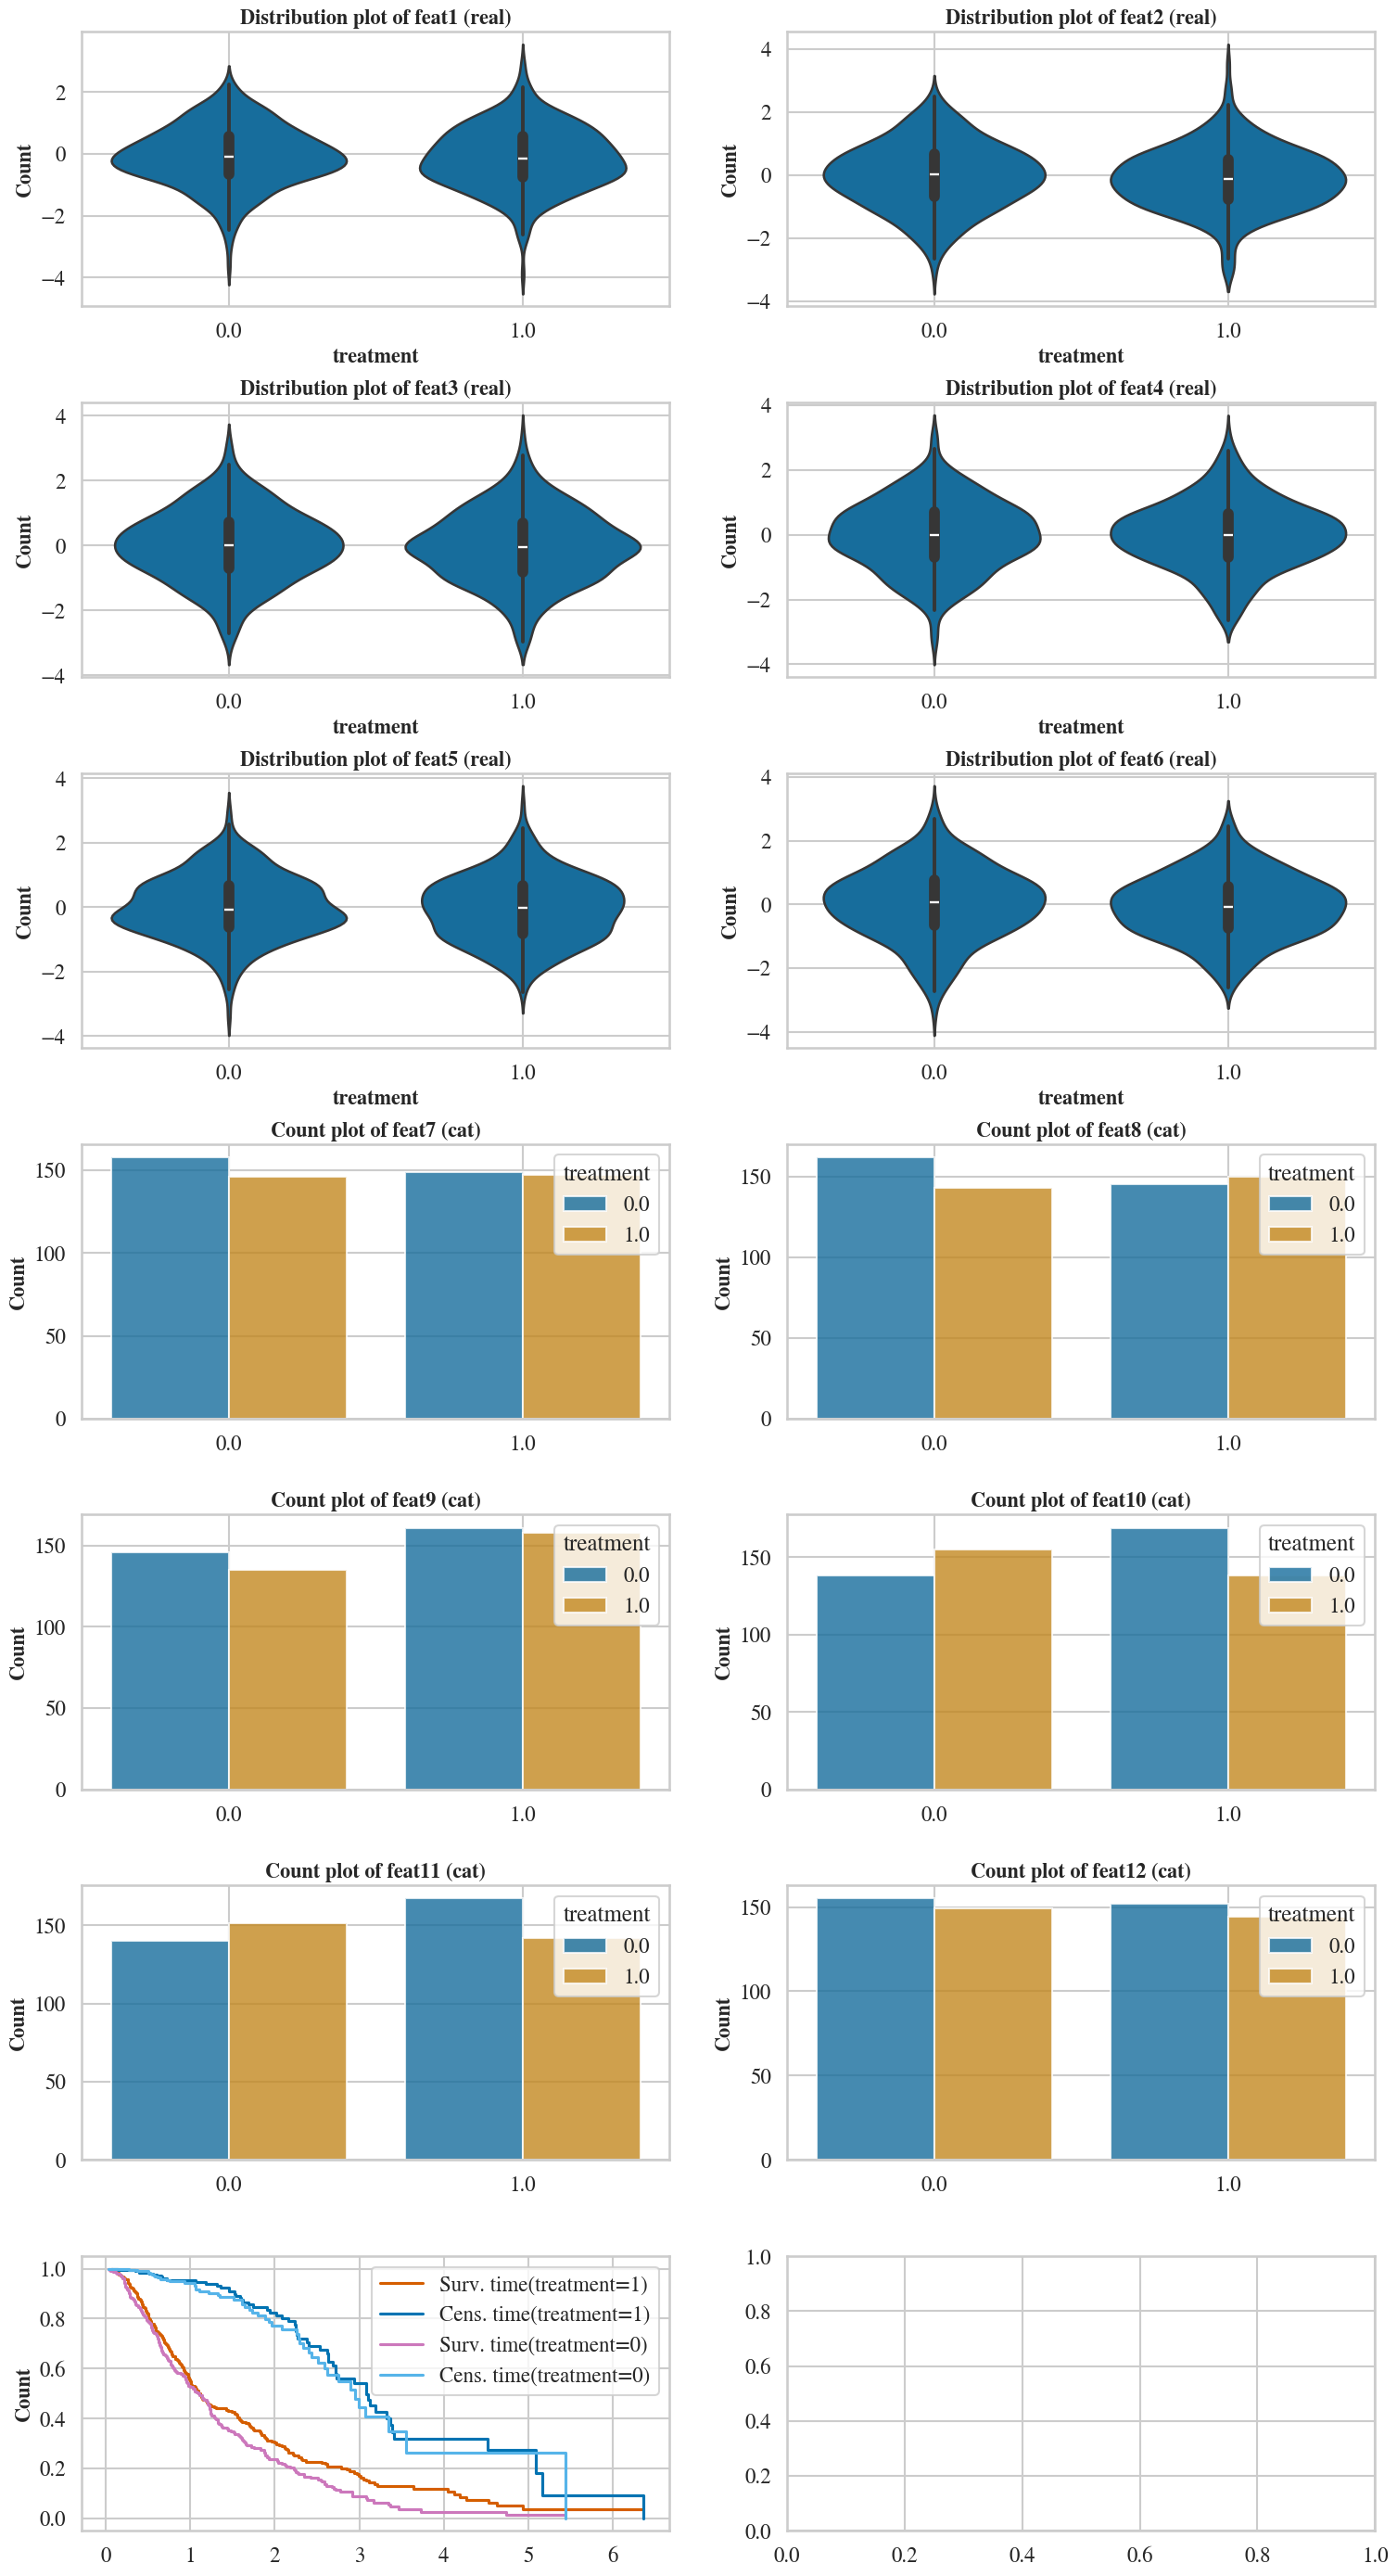

In [39]:
# TODO: Refactor
feat_types_dict_all = feat_types_dict.copy()
feat_types_dict_all.append({'name': 'treatment', 'type': 'cat', 'dim': '1', 'nclass': '2'})
visualization.plot_data(df_init.to_numpy(), feat_types_dict_all, feat_comparison_name='treatment')

In [40]:
continuous = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

In [41]:
from metrics import tableone_tests

surv_table1, _, _, _ = tableone_tests(df_init, groupby = 'treatment', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

table1 = TableOne(df_init, groupby = 'treatment', categorical=categorical, continuous=continuous, nonnormal=continuous, pval=True)
print(table1)
 

Log-rank test p-value: 0.018
                          Grouped by treatment                                                           
                                       Missing          Overall                0                1 P-Value
n                                                           600              307              293        
feat1, median [Q1,Q3]                        0  -0.1 [-0.7,0.6]  -0.1 [-0.7,0.6]  -0.2 [-0.8,0.6]   0.411
feat2, median [Q1,Q3]                        0  -0.1 [-0.8,0.6]   0.0 [-0.7,0.7]  -0.1 [-0.8,0.5]   0.232
feat3, median [Q1,Q3]                        0  -0.0 [-0.8,0.7]   0.0 [-0.7,0.7]  -0.1 [-0.8,0.7]   0.697
feat4, median [Q1,Q3]                        0  -0.0 [-0.7,0.7]  -0.0 [-0.7,0.7]  -0.0 [-0.7,0.6]   0.896
feat5, median [Q1,Q3]                        0  -0.1 [-0.7,0.7]  -0.1 [-0.6,0.7]  -0.0 [-0.8,0.7]   0.427
feat6, median [Q1,Q3]                        0   0.0 [-0.7,0.7]   0.1 [-0.7,0.8]  -0.1 [-0.7,0.6]   0.250
feat7, n (%)     

## 2. Model training and data generation

In [42]:
import surv_hivae # our model

n_generated_dataset = 100

## Toy example: Hyperparameters are set to default
data_gen_control = surv_hivae.run(df_init_control_encoded,
                                  miss_mask_control, 
                                  true_miss_mask_control,
                                  feat_types_dict,
                                  n_generated_dataset,
                                  seed=1)

Epoch: [ 0]  time: 0.1356, ELBO_train: -15.75264041, KL_z: 1.80220087, KL_s: 0.07411130, reconstruction loss: -13.87632823
Epoch: [100]  time: 9.0060, ELBO_train: -12.13261350, KL_z: 1.24252864, KL_s: 0.09292706, reconstruction loss: -10.79715780
Epoch: [200]  time: 34.5725, ELBO_train: -11.92400169, KL_z: 1.57888925, KL_s: 0.03788958, reconstruction loss: -10.30722286
Epoch: [300]  time: 60.3920, ELBO_train: -11.76906808, KL_z: 1.92257484, KL_s: 0.02228927, reconstruction loss: -9.82420398
Epoch: [400]  time: 68.9960, ELBO_train: -11.45985889, KL_z: 2.23361198, KL_s: 0.01682532, reconstruction loss: -9.20942160
Early stopping at epoch 400.
Training finished.


In [43]:
list_df_gen_control = []
for j in range(n_generated_dataset):
    df_gen_control_j = pd.DataFrame(data_gen_control[j].numpy(), columns=control_fnames)
    df_gen_control_j['treatment'] = 0
    list_df_gen_control.append(df_gen_control_j)

## 3. Individual synthetic dataset analysis

### 3.1. Statistical analysis: one generated control group vs. initial control data

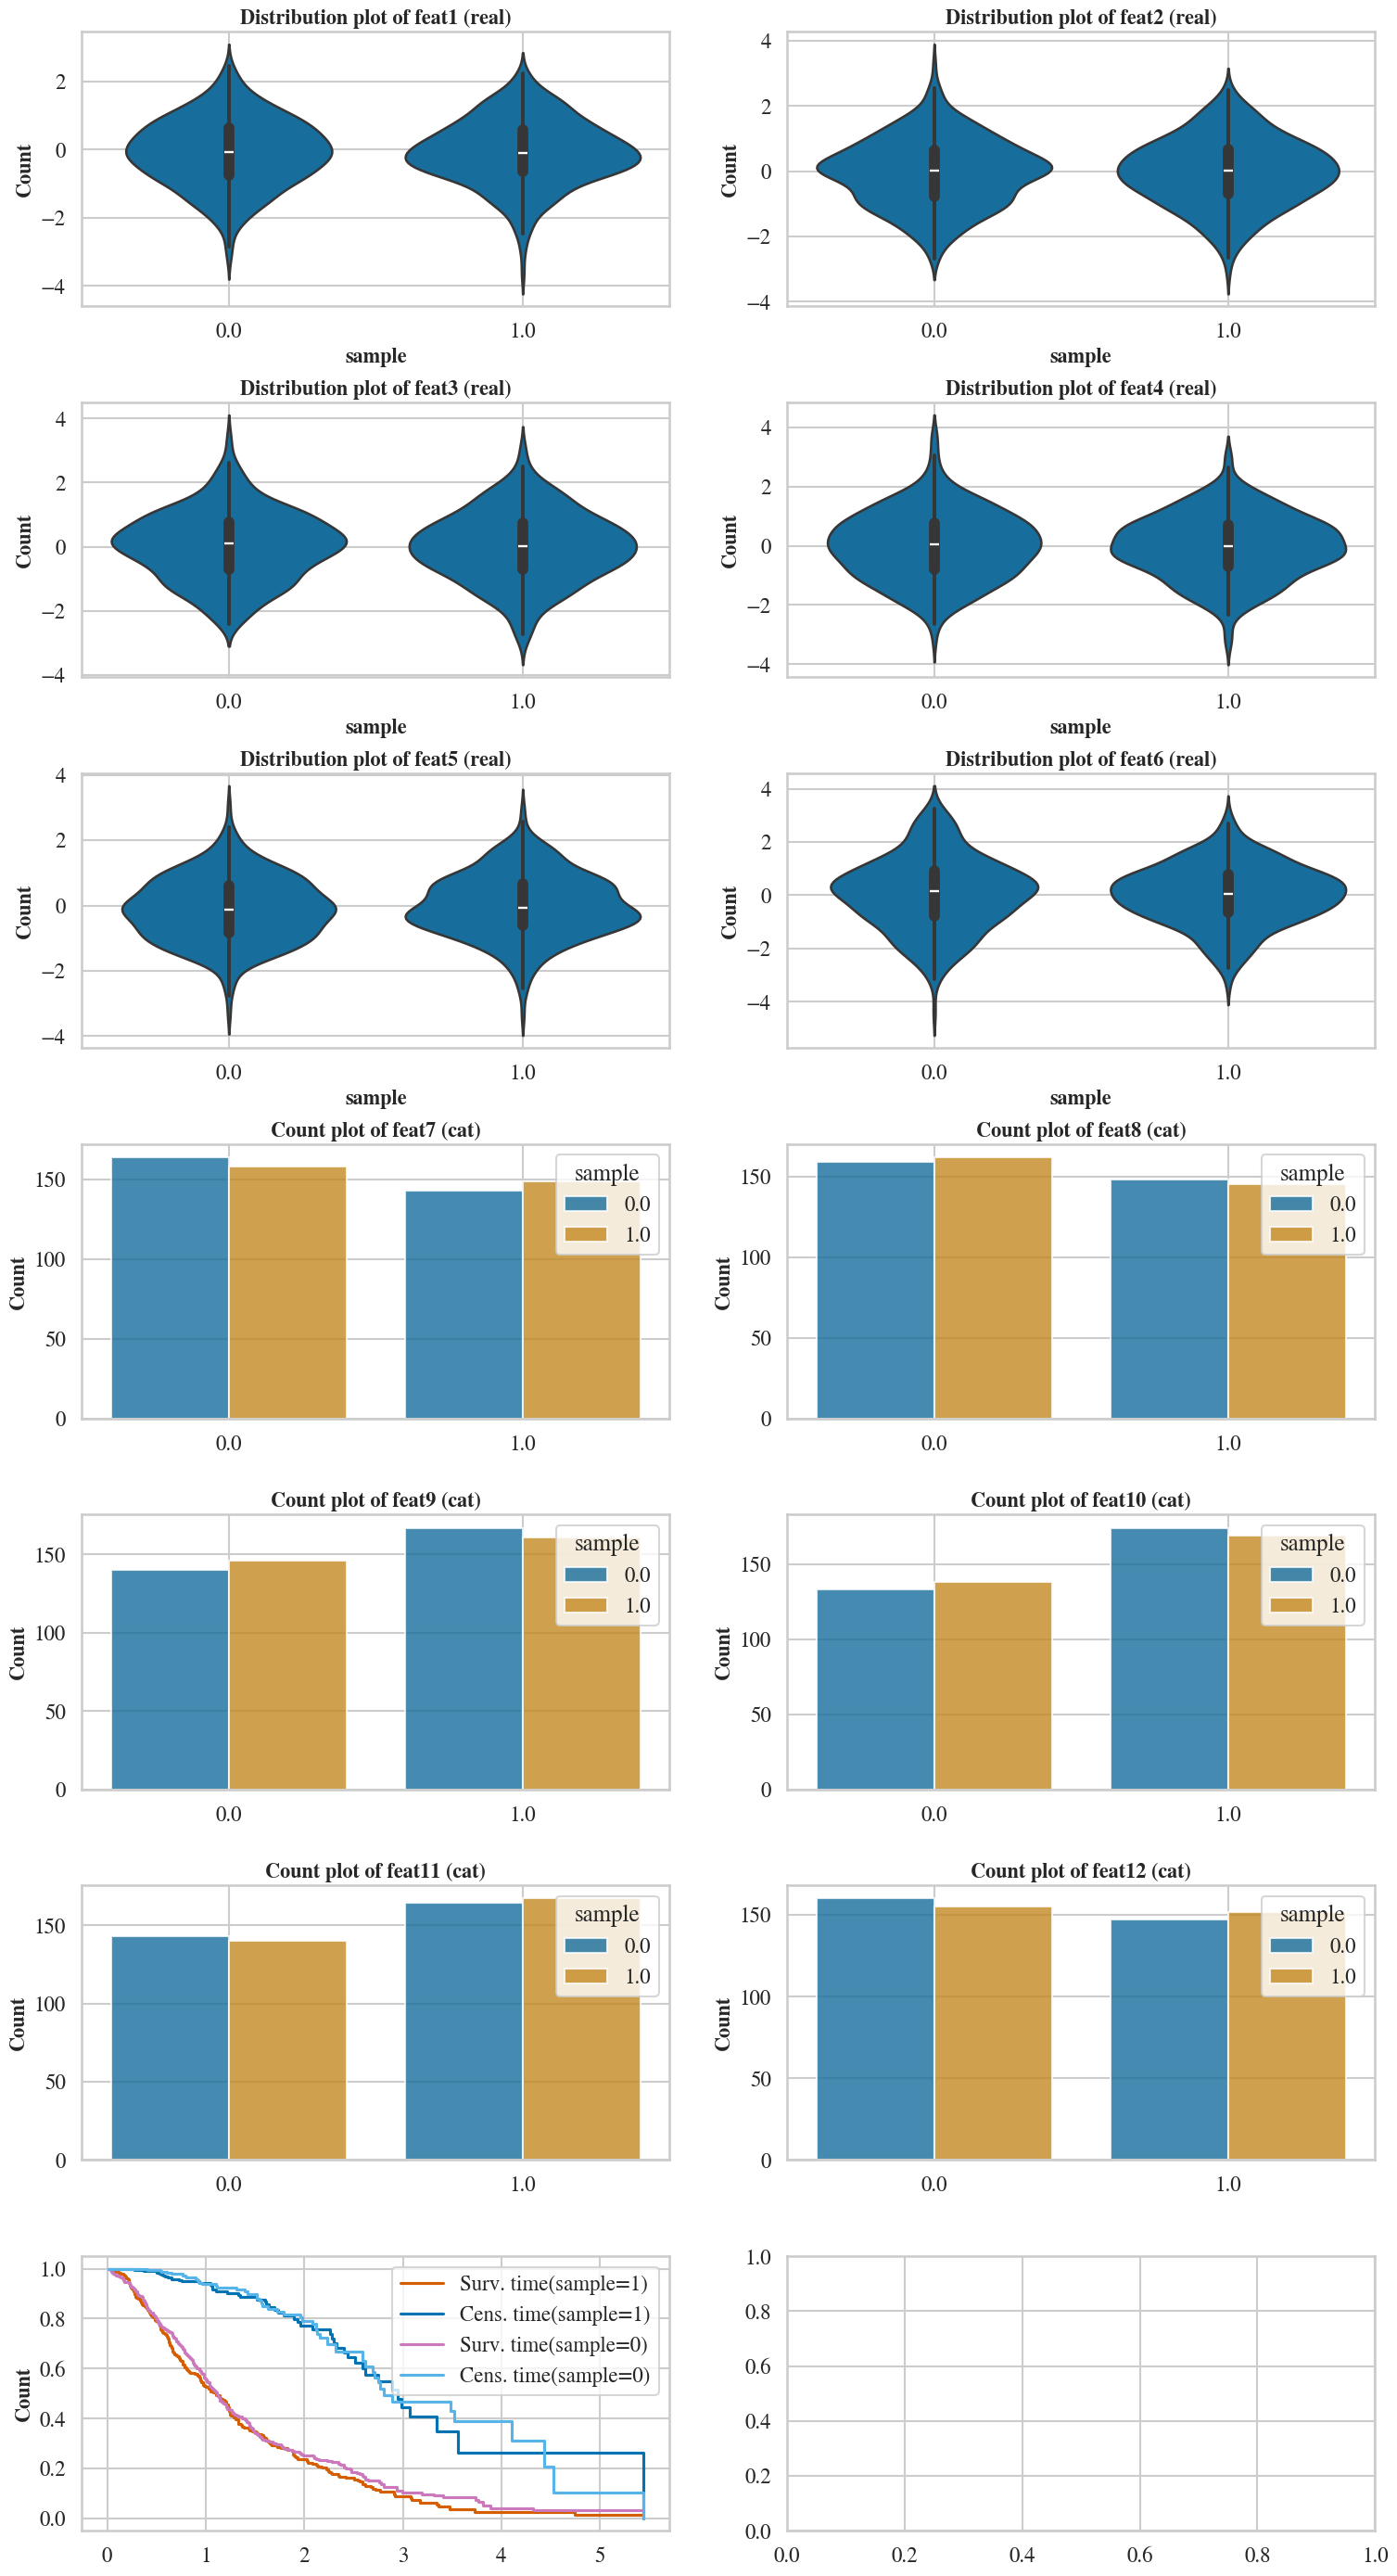

In [44]:
df_init_control_ext = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)
df_init_control_ext['sample'] = 1

sel_idx = 19
df_gen_control_ext_sel = pd.DataFrame(data_gen_control[sel_idx].numpy(), columns=control_fnames)
df_gen_control_ext_sel['sample'] = 0

feat_types_dict_ext = feat_types_dict.copy()
feat_types_dict_ext.append({'name': 'sample', 'type': 'cat', 'dim': '1', 'nclass': '2'})
df_control_sel = pd.concat([df_init_control_ext, df_gen_control_ext_sel], ignore_index=True)
visualization.plot_data(df_control_sel.to_numpy(), feat_types_dict_ext, feat_comparison_name = 'sample')

In [45]:
surv_table1, _, _, _ = tableone_tests(df_control_sel, groupby ='sample', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

table1 = TableOne(df_control_sel, categorical=categorical, continuous=continuous, groupby='sample', nonnormal=continuous, pval=True)
print(table1)

Log-rank test p-value: 0.293
                          Grouped by sample                                                           
                                    Missing          Overall                0                1 P-Value
n                                                        614              307              307        
feat1, median [Q1,Q3]                     0  -0.1 [-0.7,0.6]  -0.1 [-0.8,0.6]  -0.1 [-0.7,0.6]   0.940
feat2, median [Q1,Q3]                     0   0.0 [-0.8,0.6]   0.0 [-0.8,0.6]   0.0 [-0.7,0.7]   0.908
feat3, median [Q1,Q3]                     0   0.1 [-0.7,0.7]   0.1 [-0.7,0.8]   0.0 [-0.7,0.7]   0.711
feat4, median [Q1,Q3]                     0   0.0 [-0.8,0.8]   0.0 [-0.8,0.8]  -0.0 [-0.7,0.7]   0.894
feat5, median [Q1,Q3]                     0  -0.1 [-0.7,0.6]  -0.1 [-0.8,0.6]  -0.1 [-0.6,0.7]   0.119
feat6, median [Q1,Q3]                     0   0.1 [-0.8,0.8]   0.2 [-0.8,0.9]   0.1 [-0.7,0.8]   0.751
feat7, n (%)          0.0                   

### 3.2. Statistical analysis: one generated control group vs. initial treated data

In [46]:
sel_idx = 0
df_gen_control_sel = list_df_gen_control[sel_idx]
df_syn_sel = pd.concat([df_init_treated, df_gen_control_sel], ignore_index=True)

Observed control vs observed treated log-rank test p-value: 0.018
Generated control vs observed treated log-rank test p-value: 0.06


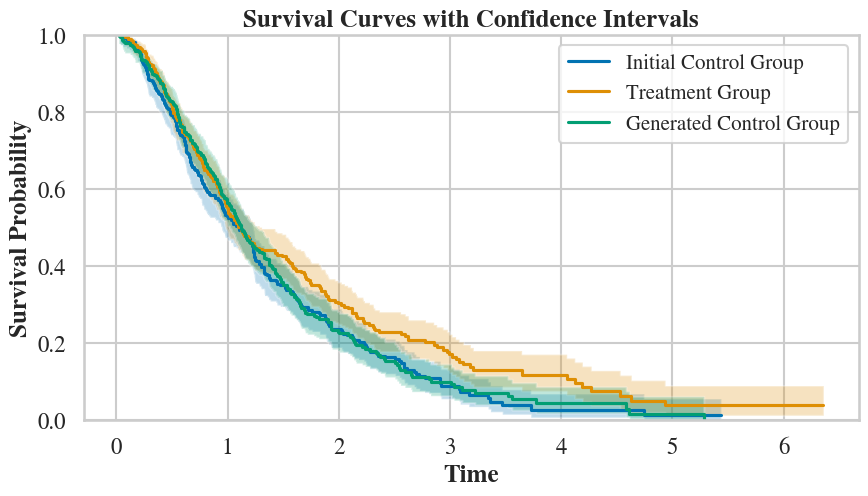

In [47]:
surv_table1, _, _, _ = tableone_tests(df_init, groupby ='treatment', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Observed control vs observed treated log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

surv_table1, _, _, _ = tableone_tests(df_syn_sel, groupby ='treatment', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Generated control vs observed treated log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

mask_c_init = df_init['treatment'] == 0
mask_t_init = df_init['treatment'] == 1
mask_c_gen  = df_syn_sel['treatment'] == 0

surv_time_control_init = df_init.loc[mask_c_init, 'time'].to_numpy()
surv_ind_control_init  = df_init.loc[mask_c_init, 'censor'].to_numpy().astype(bool)
surv_time_treated_init = df_init.loc[mask_t_init, 'time'].to_numpy()
surv_ind_treated_init  = df_init.loc[mask_t_init, 'censor'].to_numpy().astype(bool)
surv_time_control_gen  = df_syn_sel.loc[mask_c_gen, 'time'].to_numpy()
surv_ind_control_gen   = df_syn_sel.loc[mask_c_gen, 'censor'].to_numpy().astype(bool)

uniq_time_control_init, surv_prob_control_init, conf_int_control_init = kaplan_meier_estimator(surv_ind_control_init, surv_time_control_init, conf_type="log-log")
uniq_time_treated_init, surv_prob_treated_init, conf_int_treated_init = kaplan_meier_estimator(surv_ind_treated_init, surv_time_treated_init, conf_type="log-log")
uniq_time_control_gen, surv_prob_control_gen, conf_int_control_gen = kaplan_meier_estimator(surv_ind_control_gen, surv_time_control_gen, conf_type="log-log")

plt.figure(figsize=(10, 5))
plt.step(uniq_time_control_init, surv_prob_control_init, where="post", label="Initial Control Group")
plt.fill_between(uniq_time_control_init, conf_int_control_init[0], conf_int_control_init[1], alpha=0.25, step="post")

plt.step(uniq_time_treated_init, surv_prob_treated_init, where="post", label="Treatment Group")
plt.fill_between(uniq_time_treated_init, conf_int_treated_init[0], conf_int_treated_init[1], alpha=0.25, step="post")

plt.step(uniq_time_control_gen, surv_prob_control_gen, where="post", label="Generated Control Group")
plt.fill_between(uniq_time_control_gen, conf_int_control_gen[0], conf_int_control_gen[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.legend(fontsize=15)
plt.xlabel("Time", fontweight="semibold")
plt.ylabel("Survival Probability", fontweight="semibold")
plt.title("Survival Curves with Confidence Intervals", fontweight="bold")
plt.show()

## 4. Testing

### 4.1. Univariate testing: real treated vs synthetic control

In [48]:
from metrics import log_rank, cox_estimation

data_syn = []
for i in range(n_generated_dataset):
    df_gen_control = list_df_gen_control[i]
    data_syn.append(pd.concat([df_init_treated, df_gen_control], ignore_index=True))

LR_init, LR_syn = log_rank(df_init, data_syn)
coef_init, coef_syn, cox_p_value_init, cox_p_value_syn = cox_estimation(df_init, data_syn)

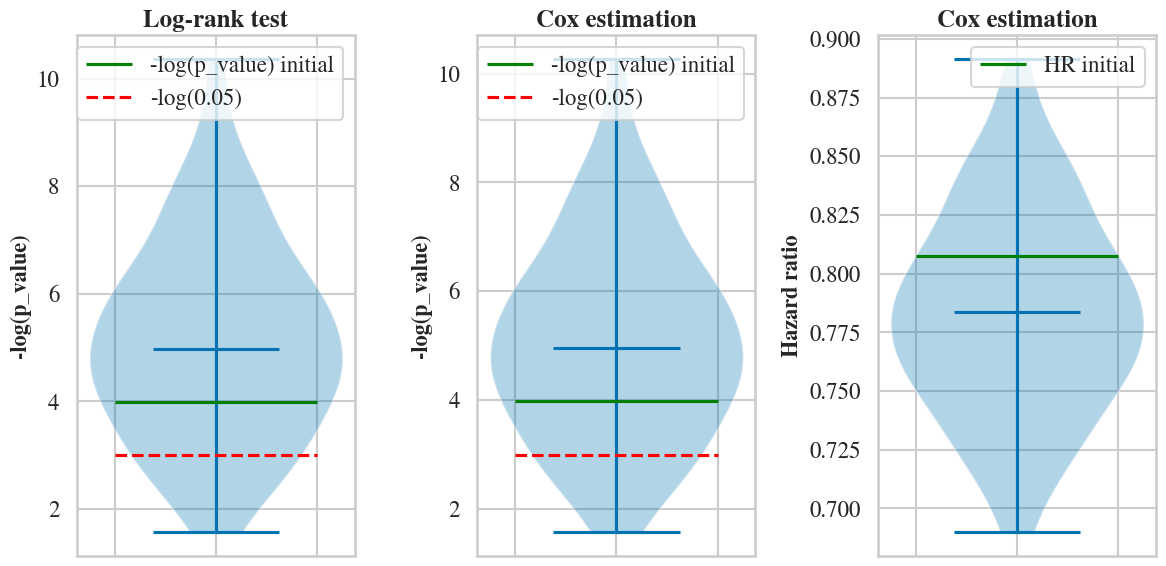

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

axs[0].violinplot(LR_syn, showmeans=False, showmedians=True)   
axs[0].hlines(LR_init, 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[0].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[0].set_xticklabels('')
axs[0].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[0].set_title('Log-rank test', fontweight="bold", size=18)
axs[0].legend(loc='upper right')

axs[1].violinplot(-np.log(cox_p_value_syn), showmeans=False, showmedians=True)
axs[1].hlines(-np.log(cox_p_value_init), 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[1].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[1].set_title('Cox estimation', fontweight="bold", size=18)
axs[1].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[1].set_xticklabels('')
axs[1].legend(loc='upper right')

axs[2].violinplot(np.exp(coef_syn), showmeans=False, showmedians=True)
axs[2].hlines(np.exp(coef_init), 0.8, 1.2, color='green', label='HR initial')
axs[2].set_title('Cox estimation', fontweight="bold", size=18)
axs[2].set_ylabel('Hazard ratio', fontweight="semibold", size=16)
axs[2].set_xticklabels('')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 4.2. Stratified testing: real treated vs synthetic control

#### 4.2.1. Categorical variable

In [50]:
from metrics import strata_log_rank, strata_cox_estimation

strata_var = categorical[0]
df_init_strata = df_init.copy(deep=True)
df_init_treated_strata = df_init_treated.copy(deep=True)

data_syn_strata = []
for i in range(n_generated_dataset):
    df_gen_control_strata = pd.DataFrame(data_gen_control[i].numpy(), columns=control_fnames)
    df_gen_control_strata['treatment'] = 0
    data_syn_strata.append(pd.concat([df_init_treated_strata, df_gen_control_strata], ignore_index=True))

strata_LR_init, strata_LR_syn = strata_log_rank(df_init_strata, data_syn_strata, strata=strata_var)
strata_coef_init, strata_coef_syn, strata_cox_p_value_init, strata_cox_p_value_syn = strata_cox_estimation(df_init_strata, data_syn_strata, strata=strata_var)

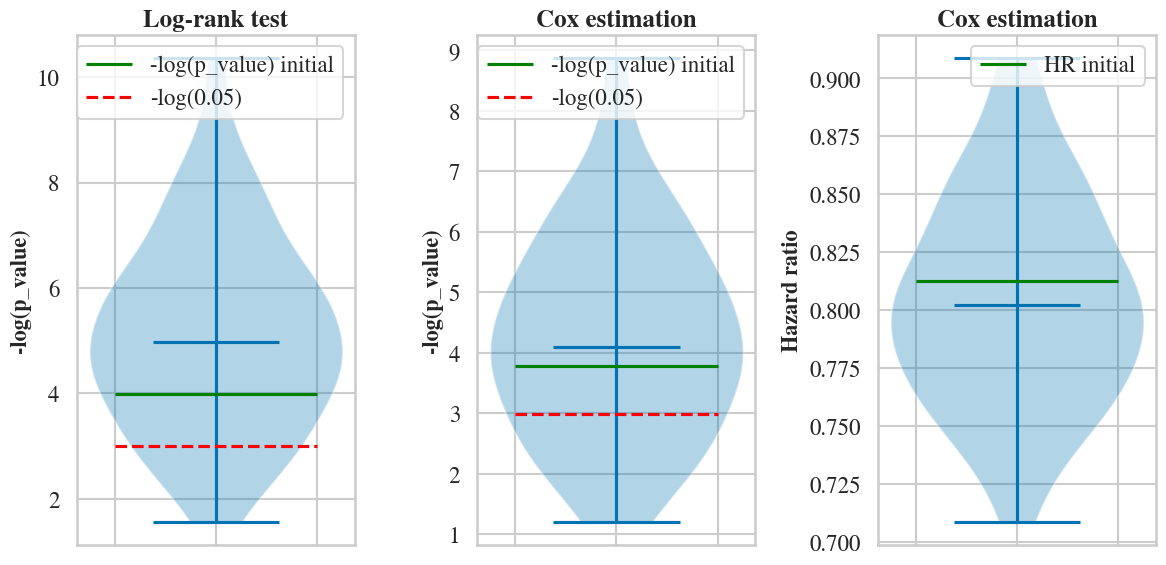

In [51]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

axs[0].violinplot(strata_LR_syn, showmeans=False, showmedians=True)   
axs[0].hlines(strata_LR_init, 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[0].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[0].set_xticklabels('')
axs[0].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[0].set_title('Log-rank test', fontweight="bold", size=18)
axs[0].legend(loc='upper right')

axs[1].violinplot(-np.log(strata_cox_p_value_syn), showmeans=False, showmedians=True)
axs[1].hlines(-np.log(strata_cox_p_value_init), 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[1].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[1].set_title('Cox estimation', fontweight="bold", size=18)
axs[1].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[1].set_xticklabels('')
axs[1].legend(loc='upper right')

axs[2].violinplot(np.exp(strata_coef_syn), showmeans=False, showmedians=True)
axs[2].hlines(np.exp(strata_coef_init), 0.8, 1.2, color='green', label='HR initial')
axs[2].set_title('Cox estimation', fontweight="bold", size=18)
axs[2].set_ylabel('Hazard ratio', fontweight="semibold", size=16)
axs[2].set_xticklabels('')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

#### 4.2.2. Continous variable

In [52]:
# Define the stratified variable
strata_var = continuous[0]
str_strata_var = 'is_low_' + strata_var
strata_var_threshold = df_init[strata_var].quantile(.4)

df_init_strata = df_init.copy(deep=True)
df_init_strata[str_strata_var] = (df_init_strata[strata_var] < strata_var_threshold).astype(int)
df_init_treated_strata = df_init_treated.copy(deep=True)
df_init_treated_strata[str_strata_var] = (df_init_treated_strata[strata_var] < strata_var_threshold).astype(int)

data_syn_strata = []
for i in range(n_generated_dataset):
    df_gen_control_strata = pd.DataFrame(data_gen_control[i].numpy(), columns=control_fnames)
    df_gen_control_strata['treatment'] = 0
    df_gen_control_strata[str_strata_var] = (df_gen_control_strata[strata_var] < strata_var_threshold).astype(int)
    data_syn_strata.append(pd.concat([df_init_treated_strata, df_gen_control_strata], ignore_index=True))

strata_LR_init, strata_LR_syn = strata_log_rank(df_init_strata, data_syn_strata, strata=str_strata_var)
strata_coef_init, strata_coef_syn, strata_cox_p_value_init, strata_cox_p_value_syn = strata_cox_estimation(df_init_strata, data_syn_strata, strata=str_strata_var)

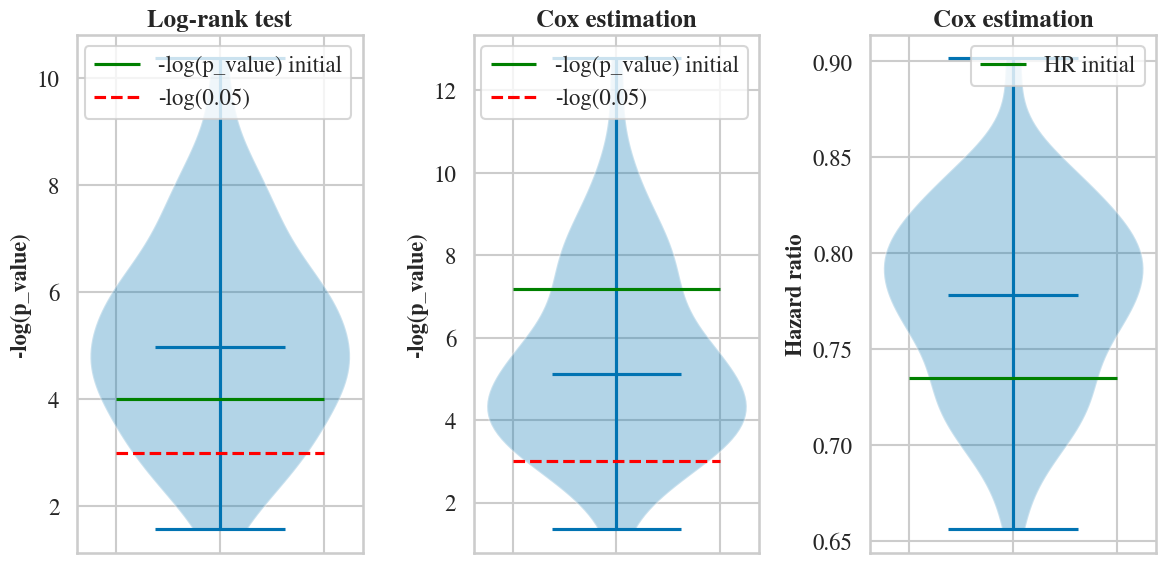

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

axs[0].violinplot(strata_LR_syn, showmeans=False, showmedians=True)   
axs[0].hlines(strata_LR_init, 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[0].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[0].set_xticklabels('')
axs[0].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[0].set_title('Log-rank test', fontweight="bold", size=18)
axs[0].legend(loc='upper right')

axs[1].violinplot(-np.log(strata_cox_p_value_syn), showmeans=False, showmedians=True)
axs[1].hlines(-np.log(strata_cox_p_value_init), 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[1].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[1].set_title('Cox estimation', fontweight="bold", size=18)
axs[1].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[1].set_xticklabels('')
axs[1].legend(loc='upper right')

axs[2].violinplot(np.exp(strata_coef_syn), showmeans=False, showmedians=True)
axs[2].hlines(np.exp(strata_coef_init), 0.8, 1.2, color='green', label='HR initial')
axs[2].set_title('Cox estimation', fontweight="bold", size=18)
axs[2].set_ylabel('Hazard ratio', fontweight="semibold", size=16)
axs[2].set_xticklabels('')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Model evaluation

### 5.1. Metrics computed per generated dataset

In [54]:
from metrics import general_metrics_modular


simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}


score_df = general_metrics_modular(df_init_control, list_df_gen_control, 
                                   'hivae', simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                   categorical=categorical, continuous=continuous, nonnormal=continuous)

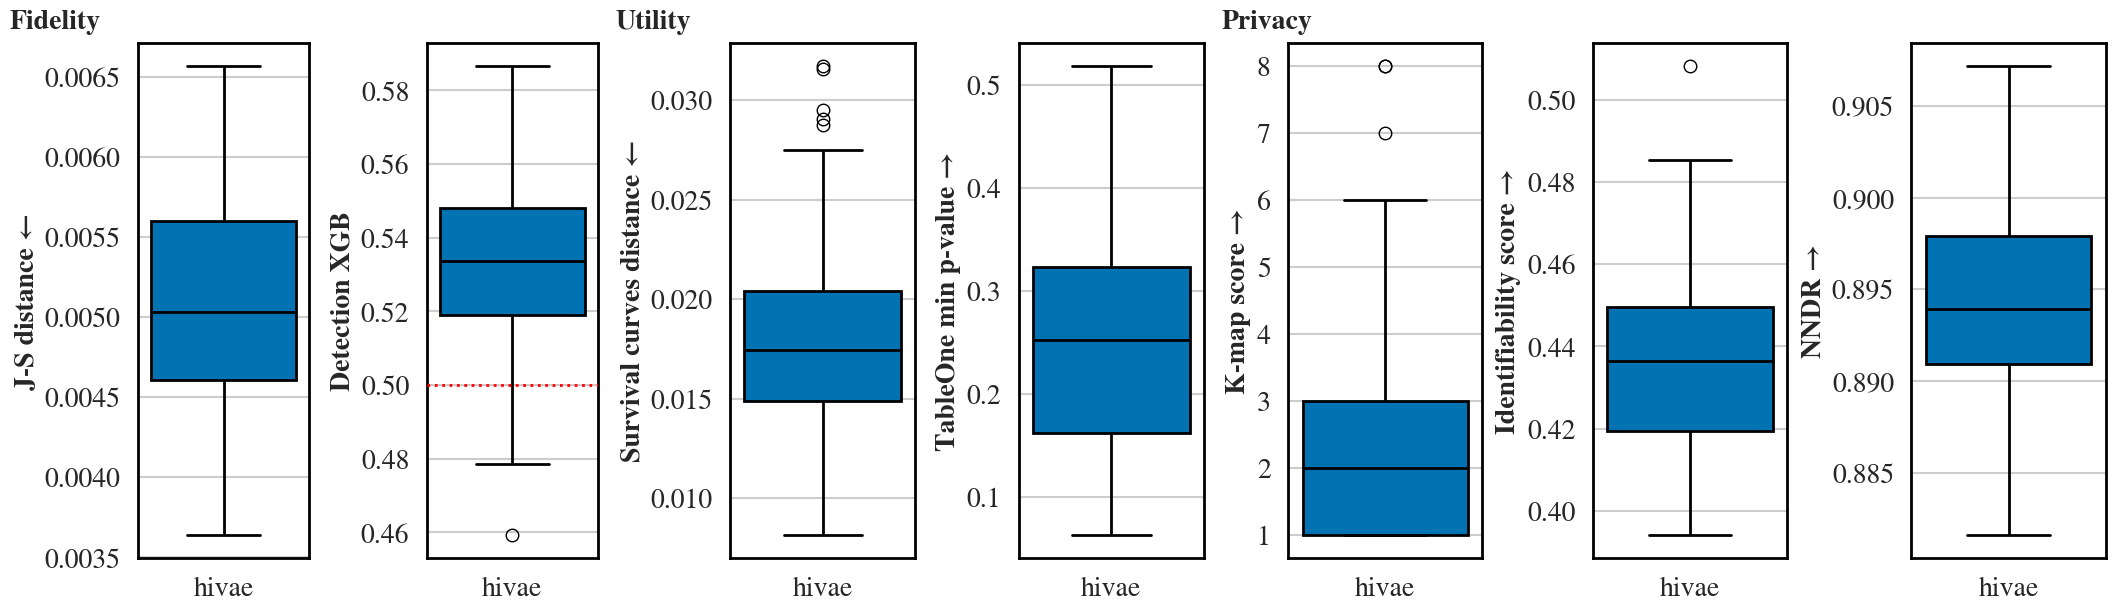

In [117]:
from visualization import visualize_grouped_perf
dict_metrics = {"Fidelity": [["J-S distance", "min"], ["Detection XGB", 0.5]],
                "Utility": [["Survival curves distance", "min"], ['TableOne min p-value', 'max']],
                "Privacy": [["K-map score", "max"], ["Identifiability score", 0.5], ["NNDR", "max"]]}
visualize_grouped_perf(score_df, dict_metrics)

### 5.2. Membership Inference Attack

In [110]:
# In order to run a membership inference attack on simulated data, we can just generate more data following the same distribution.
def _fresh_control(seed):
    c, _, ty = simulation(treatment_effect, n_samples, independent, feature_types_list,
                          n_features_bytype, n_active_features, p_treated, shape_T, shape_C,
                          scale_C, scale_C_indep, data_types_create, seed=seed)
    d = ty[['name']].to_dict()['name']; d.pop(12, None)
    c = c.rename(columns=d)
    c['treatment'] = c.pop('treatment')
    c['censor'] = c['censor'].astype('float64')
    return c

df_new_control = _fresh_control(seed+1)

In [111]:
from metrics import membership_inference_attack
mia_results_dict = membership_inference_attack(df_init_control, df_new_control, list_df_gen_control, categorical=categorical+['censor', 'treatment'], bootstrap=True, return_boot_auc=True)

In [112]:
mia_score_df = pd.DataFrame()
mia_score_df['AUC-ROC'] = mia_results_dict['boot_auc']
mia_score_df['generator'] = 'hivae'

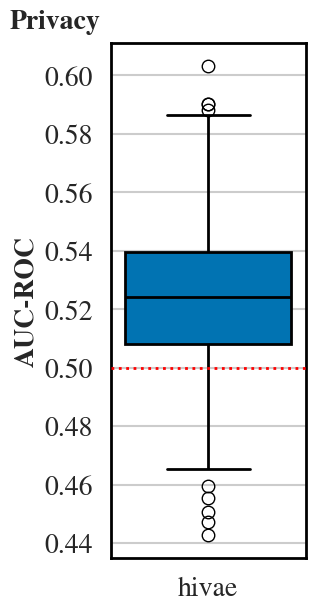

In [113]:
visualize_grouped_perf(mia_score_df, {"Privacy": [["AUC-ROC", 0.5]]})

## Bonus: Self baseline

In [ ]:
## To have a baseline to compare our generated dataset results to, we parallelly compute the metrics on a list of datasets
## generated using the same distribution.

list_df_new_control = [_fresh_control(seed+2+i) for i in range (100)]

score_df_baseline = general_metrics_modular(df_init_control, list_df_new_control, 
                                            'self', simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                            categorical=categorical, continuous=continuous, nonnormal=continuous)

In [119]:
score_df_complete = pd.concat([score_df, score_df_baseline], ignore_index=True)

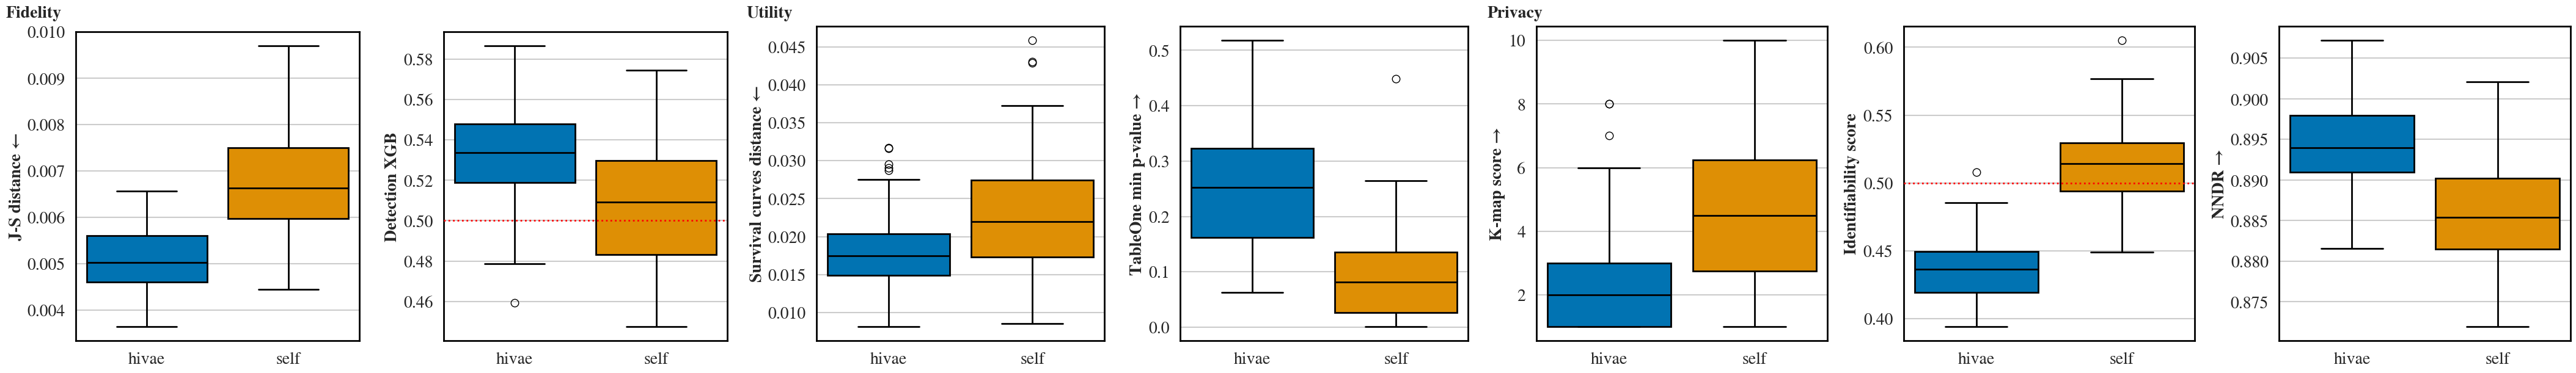

In [120]:
visualize_grouped_perf(score_df_complete, dict_metrics)